In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Cargar dataset
df = pd.read_csv("ENDES_Anemia_Hogar_2019_2024_LIMPIO.csv")

In [3]:
#Se muestra tipos de datos y cantidad de valores no nulos.
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 105027 entries, 0 to 105026
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ANO                105027 non-null  int64  
 1   CASEID             105027 non-null  str    
 2   HHID               105027 non-null  int64  
 3   Edad_Meses         105027 non-null  float64
 4   Peso_kg            105027 non-null  float64
 5   Talla_cm           105027 non-null  float64
 6   Hemoglobina        105027 non-null  float64
 7   Zscore_Talla_Edad  105027 non-null  float64
 8   Zscore_Peso_Edad   105027 non-null  float64
 9   Zscore_Peso_Talla  105027 non-null  float64
 10  Zscore_IMC         105027 non-null  float64
 11  Nivel_Anemia       105027 non-null  str    
 12  Departamento       105027 non-null  str    
 13  Area_Residencia    105027 non-null  str    
 14  Altitud            105027 non-null  int64  
 15  UBIGEO             105027 non-null  int64  
 16  Factor_Expans

In [7]:
#Se muetra las primeras 5 filas del df
df.head()

,ANO,CASEID,HHID,Edad_Meses,Peso_kg,Talla_cm,Hemoglobina,Zscore_Talla_Edad,Zscore_Peso_Edad,Zscore_Peso_Talla,Zscore_IMC,Nivel_Anemia,Departamento,Area_Residencia,Altitud,UBIGEO,Factor_Expansion,Estrato,Conglomerado
0,2019,000100201 2,100201,8.0,10.7,72.7,12.1,0.63,1.85,2.00,1.95,Sin anemia,Amazonas,Urbana,2356,10101,0.142155,3,1
1,2019,000102801 2,102801,18.0,9.3,79.0,12.6,-0.69,-0.84,-0.70,-0.61,Sin anemia,Amazonas,Urbana,2356,10101,0.142155,3,1
2,2019,000102801 2,102801,52.0,18.2,105.9,12.0,0.09,0.52,0.70,0.71,Sin anemia,Amazonas,Urbana,2356,10101,0.142155,3,1
3,2019,000104801 2,104801,42.0,14.5,96.3,12.4,-0.77,-0.30,0.21,0.24,Sin anemia,Amazonas,Urbana,2356,10101,0.142155,3,1
4,2019,000113601 2,113601,8.0,8.5,68.5,8.7,-0.10,0.55,0.86,0.81,Moderada,Amazonas,Urbana,2356,10101,0.142155,3,1


In [ ]:
#Se genera estadisticas de las columnas numericas
df.describe()

In [ ]:
#Se cuenta cuantas veces se repite un valor unico
df['ANO'].value_counts()

In [ ]:
#Se muestra la cantidad total de valores nulos de todas las columnas
df.isnull().sum()

In [ ]:
#Se muestra la cantidad total de filas duplicadas completamente
df.duplicated().sum()

/tmp/ipykernel_5392/2748502105.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo.index, y=conteo.values, palette='RdYlGn_r')


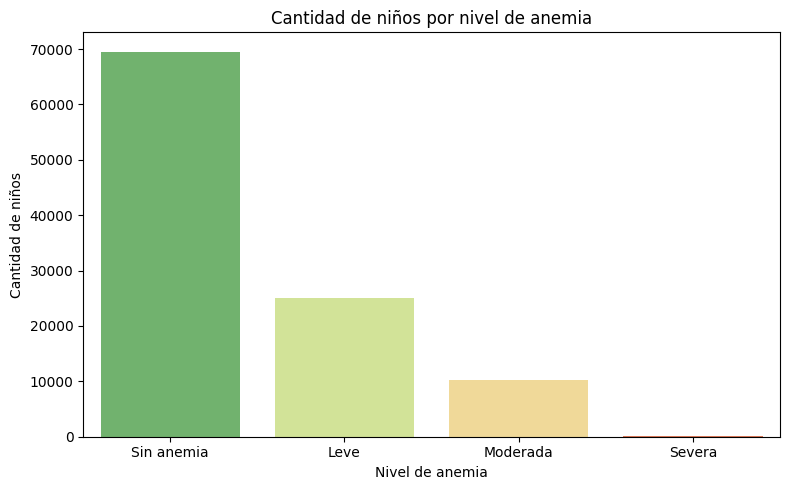

In [ ]:
# Se cuenta cuántos niños hay por cada nivel de anemia
conteo = df['Nivel_Anemia'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=conteo.index, y=conteo.values, palette='RdYlGn_r')
plt.title('Cantidad de niños por nivel de anemia')
plt.xlabel('Nivel de anemia')
plt.ylabel('Cantidad de niños')
plt.tight_layout()
plt.show()

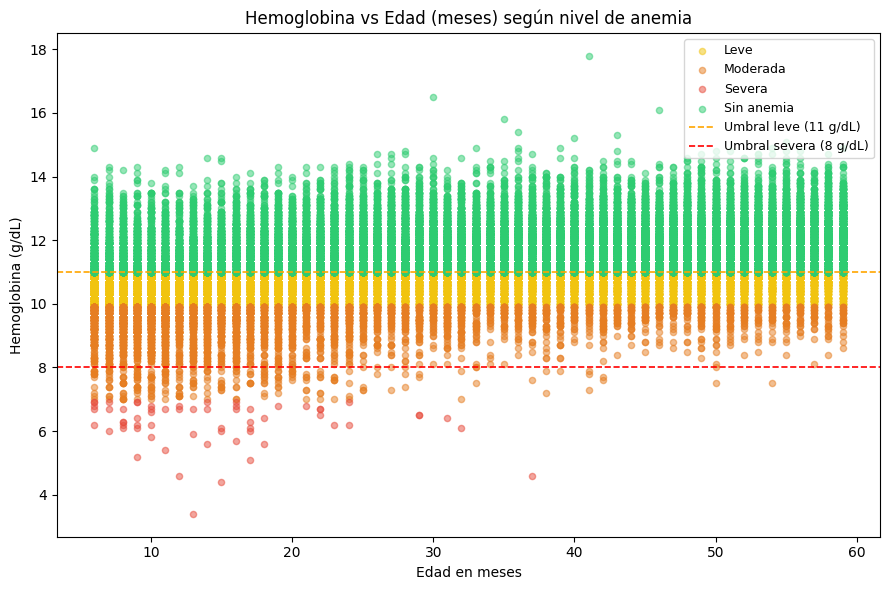

In [18]:
# Se toma una muestra de 4000 filas para que el grafico no tarde
muestra = df.sample(n=50000, random_state=42)


plt.figure(figsize=(9, 6))

colores = {
    'Sin anemia': '#2ecc71',
    'Leve':       '#f1c40f',
    'Moderada':   '#e67e22',
    'Severa':     '#e74c3c'
}
for nivel, grupo in muestra.groupby('Nivel_Anemia'):
    plt.scatter(
        grupo['Edad_Meses'],
        grupo['Hemoglobina'],
        label=nivel,
        color=colores.get(nivel, 'gray'),
        alpha=0.5,
        s=20
    )

plt.axhline(y=11.0, color='orange', linestyle='--', linewidth=1.2, label='Umbral leve (11 g/dL)')
plt.axhline(y=8.0,  color='red',    linestyle='--', linewidth=1.2, label='Umbral severa (8 g/dL)')

plt.title('Hemoglobina vs Edad (meses) según nivel de anemia')
plt.xlabel('Edad en meses')
plt.ylabel('Hemoglobina (g/dL)')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5392/2463747053.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prevalencia.values, y=prevalencia.index, palette='Reds_r')


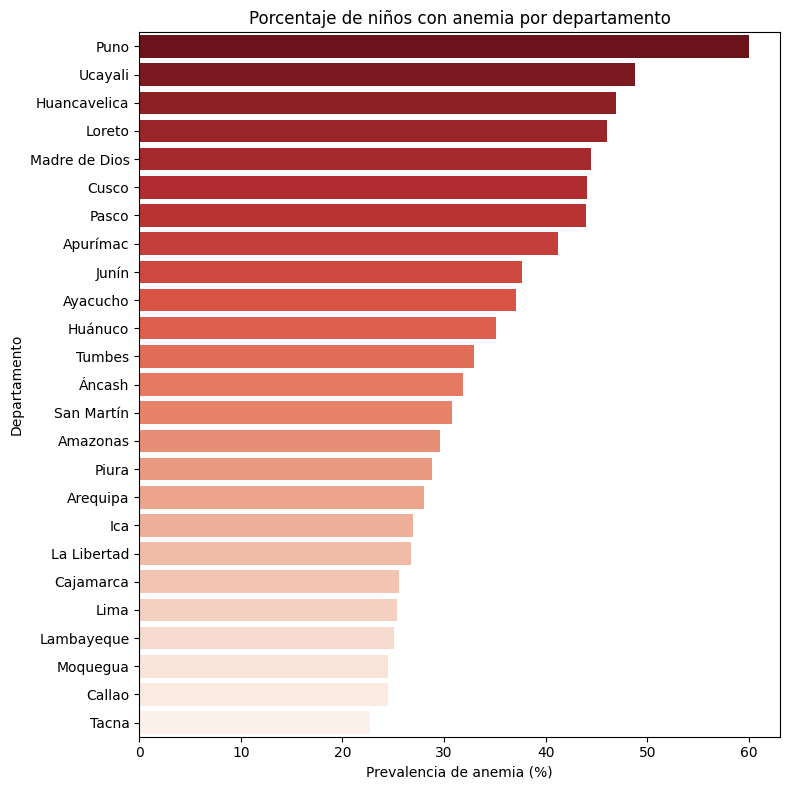

In [16]:
# Se marca con True a los niños que tienen algun tipo de anemia
df['Tiene_Anemia'] = df['Nivel_Anemia'] != 'Sin anemia'

prevalencia = df.groupby('Departamento')['Tiene_Anemia'].mean() * 100
prevalencia = prevalencia.sort_values(ascending=False)


plt.figure(figsize=(8, 8))
sns.barplot(x=prevalencia.values, y=prevalencia.index, palette='Reds_r')
plt.title('Porcentaje de niños con anemia por departamento')
plt.xlabel('Prevalencia de anemia (%)')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

In [20]:
df['Departamento'].unique()

<StringArray>
[     'Amazonas',        'Áncash',      'Apurímac',      'Arequipa',
      'Ayacucho',     'Cajamarca',        'Callao',         'Cusco',
  'Huancavelica',       'Huánuco',           'Ica',         'Junín',
   'La Libertad',    'Lambayeque',          'Lima',        'Loreto',
 'Madre de Dios',      'Moquegua',         'Pasco',         'Piura',
          'Puno',    'San Martín',         'Tacna',        'Tumbes',
       'Ucayali']
Length: 25, dtype: str